##### 1. Load Libraries

In [1]:
import os
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve
)
from sklearn.preprocessing import(
    LabelEncoder,
    StandardScaler
)
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np
import json
import sys, re, threading
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import math
import optuna
from optuna.exceptions import TrialPruned
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Layer, Embedding,
    LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Add
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, Callback
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# -----------------------------------------------------------------------------
# Silence harmless low-level C++/CUDA/XLA messages that TensorFlow prints straight
# to file descriptor 2, which TF_CPP_MIN_LOG_LEVEL alone does not stop. Examples:
#   "Skipping the delay kernel, measurement accuracy will be reduced"
#   "'+ptx85' is not a recognized feature for this target (ignoring feature)"
#   "could not open file to read NUMA node ... built without NUMA support"
# A background thread drops these known lines while letting real training output
# (stdout) and genuine errors through. Installed once per kernel session.
# -----------------------------------------------------------------------------

if not globals().get("_STDERR_FILTER_INSTALLED"):
    _NOISE = re.compile(
        r"^[IWEF]\d{4} "                                  # absl logs: I0000/W0000/E0000 ...
        r"|^\d{4}-\d\d-\d\d \d\d:\d\d:\d\d\.\d+: [IWEF] "  # absl logs: 2026-..-..: I/W/E ...
        r"|recognized feature for this target"            # LLVM "+ptxNN" PTX feature notice
        r"|ignoring feature"
        r"|NUMA support"                                  # NUMA-node warnings
        r"|All log messages before absl"
        r"|oneDNN custom operations"
        r"|different numerical results due to"
        r"|TensorFlow binary is optimized"
        r"|To enable the following instructions"
    )
    _orig_err_fd = os.dup(2)
    _pipe_r, _pipe_w = os.pipe()
    os.dup2(_pipe_w, 2)
    os.close(_pipe_w)

    def _filter_stderr(reader_fd=_pipe_r, out_fd=_orig_err_fd, pattern=_NOISE):
        with os.fdopen(reader_fd, "r", errors="replace") as reader:
            for line in reader:
                if not pattern.search(line):
                    os.write(out_fd, line.encode(errors="replace"))

    threading.Thread(target=_filter_stderr, daemon=True).start()
    _STDERR_FILTER_INSTALLED = True

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"TensorFlow {tf.__version__} - GPU(s) found: {[g.name for g in gpus]}")
else:
    print(f"TensorFlow {tf.__version__} - no GPU found, running on CPU.")

# -----------------------------
# Reproducibility
# -----------------------------
# Seeds Python, NumPy and TensorFlow in one call, matching the random_state=42 used
# throughout the RF/XG notebooks. Without it, weight initialisation and batch shuffling
# vary run to run -- the reason identical hyperparameters once produced 44.96% in one
# run and 99.68% in another.
tf.keras.utils.set_random_seed(42)

2026-08-07 14:34:09.116946: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-07 14:34:09.134044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-07 14:34:09.152028: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-07 14:34:09.156607: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-07 14:34:09.168976: I tensorflow/core/platform/cpu_feature_guar

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow 2.17.0 - GPU(s) found: ['/physical_device:GPU:0']


##### 2. Load and Add Target Columns
In this cell, data is read from the csv files in the "data" folder and imported as dataframes in Python. The target column is added, then encoded to a numerical value for the model. The target map is exported to keep track of which classification value is associated with which species. This export can be turned on/off based on the argument given to the function (shown in the code comment below). 

In [2]:
# dictionary for value insertion for target column
# Keys are matched against file names, so keep these specific enough to avoid overlap.
targets = {
    "PAO1": "PAO1",
    "STAPH": "Staph",
    "Corn": "Corn",
    "E.coli": "E.coli",
    "Malt": "Malt",
    "FAE": "FAE"
}

def find_csv_files(data_path):
    if not os.path.isdir(data_path):
        raise FileNotFoundError(f"Data folder not found: {data_path}")

    csv_files = []
    for root, dirs, files in os.walk(data_path):
        dirs[:] = sorted(d for d in dirs if not d.startswith("."))
        for file_name in sorted(files):
            if file_name.endswith(".csv"):
                csv_files.append(os.path.join(root, file_name))

    return sorted(csv_files)

def read_all_csvs_to_df(data_path, export_target_map=False):
    dataframes = []

    file_list = find_csv_files(data_path)
    if not file_list:
        raise ValueError(f"No CSV files found in: {data_path}")

    for i, file_path in enumerate(file_list):
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path, header=None)

        if i != 0:
            df = df.iloc[1:].reset_index(drop=True)

        # adding the target column values based on the target dictionary above
        target_value = next((value for key, value in targets.items() if key.lower() in file_name.lower()), None)  

        if target_value is None:
            raise ValueError(f"No target mapping found for file: {file_name}")

        labeled_df = df.copy()
        labeled_df["target"] = target_value
        dataframes.append(labeled_df)

    # Some added files have a different number of feature columns. Keep only columns
    # shared by all files so the Transformer never receives NaNs from column misalignment.
    combined_df = pd.concat(dataframes, ignore_index=True, join="inner").copy()

    # label encoding for RF model 
    label_encoder = LabelEncoder()
    combined_df["target_encoded"] = label_encoder.fit_transform(combined_df["target"])

    # exporting target value map
    if export_target_map:
        target_map = {
            str(original): int(encoded)
            for original, encoded in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))
        }

        json_path = os.path.join(os.getcwd(), "target_encoding_map.json")
        with open(json_path, "w") as f:
            json.dump(target_map, f, indent=4)


    return combined_df


# accessing the main data folder
data_path = os.path.join("..", "data", "six_single_species") #only mixed ratio data
df = read_all_csvs_to_df(data_path, export_target_map=False) # CHANGE ARGUMENT TO TRUE

##### 3. Label Data and Drop Target Column
In this cell, feature labels are changed and the target column is dropped. When importing the data from a csv into the dataframe, the feature labels (wavelengths) are changed to a numerical scale from 0 to the number of features/columns in the data. This remapping is exported as a json file to keep track of what is being looked at. This export can also be disabled through argument changes in the function. Since the logic of the previous cell required the string target column, it gets removed here instead of the previous cell.

In [3]:
def label_data(dataframe, export_feature_map=False):
    target_idx = dataframe.columns.get_loc("target")
    feature_cols = dataframe.columns[:target_idx]

    feature_values = dataframe.iloc[0, :target_idx]
    feature_labels = range(1, len(feature_cols) + 1)

    clean_df = dataframe.iloc[1:].reset_index(drop=True).copy()
    clean_df = clean_df.rename(columns=dict(zip(feature_cols, feature_labels)))

    if export_feature_map:
        feature_map = dict(zip(feature_labels, feature_values))
        json_path = os.path.join(os.getcwd(), "feature_map.json")
        with open(json_path, "w") as f:
            json.dump(feature_map, f, indent=4)

    clean_df = clean_df.drop(columns=['target'], errors="ignore")

    return clean_df


#for testing
clean_df = label_data(df, export_feature_map=False) # CHANGE ARGUMENT TO TRUE

##### 4. Splitting for Transformer
In this cell, the data is being split for an 80-20 training and testing split.

In [4]:
# -----------------------------
# Prepare features and labels
# -----------------------------
if "target_encoded" not in clean_df.columns:
    raise ValueError("clean_df must contain a 'target_encoded' column.")

# X = all feature columns, y = encoded class labels
X_df = clean_df.drop(columns=["target_encoded"]).astype(np.float32)
feature_columns = X_df.columns
X = X_df.to_numpy(dtype=np.float32)
y = clean_df["target_encoded"].astype(int).values

if X.ndim != 2:
    raise ValueError(f"Expected X to be 2D before scaling, got shape {X.shape}")
if np.isnan(X).any():
    raise ValueError("X contains NaN values. Check CSV column alignment before training.")

# Number of classes
n_classes = len(np.unique(y))
print("Number of classes:", n_classes)
print("X shape before scaling:", X.shape)

# -----------------------------
# Standardize features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns, index=X_df.index)

# -----------------------------
# One-hot encode labels
# -----------------------------
y_cat = to_categorical(y, num_classes=n_classes).astype(np.float32)


def add_white_noise_to_features(
    X: pd.DataFrame,
    noise_level: float = 0.05,
    random_state: int = 42,
    relative: bool = True
) -> pd.DataFrame:
    """
    Create a noisy copy of spectral feature rows by adding Gaussian white noise.

    Parameters:
        X (pd.DataFrame): Feature dataframe only (no target column).
        noise_level (float): Noise strength.
            If relative=True, this is multiplied by each row's std.
            If relative=False, this is used as the std of the noise directly.
        random_state (int): Seed for reproducibility.
        relative (bool): If True, scale noise by each row's spectral std.
                         If False, use fixed std for all features.

    Returns:
        X_noisy (pd.DataFrame): Noisy copy of X with same shape/index/columns.
    """
    rng = np.random.default_rng(random_state)
    X_values = X.to_numpy(dtype=float)

    if relative:
        row_std = X_values.std(axis=1, keepdims=True)
        row_std = np.where(row_std == 0, 1e-8, row_std)
        noise = rng.normal(loc=0.0, scale=noise_level * row_std, size=X_values.shape)
    else:
        noise = rng.normal(loc=0.0, scale=noise_level, size=X_values.shape)

    X_noisy = X_values + noise

    return pd.DataFrame(X_noisy, columns=X.columns, index=X.index)


# -----------------------------
# Train-test split
# -----------------------------
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_scaled_df,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y   # stratify with integer labels, not one-hot labels
)

# Duplicate the held-out 0.2 test dataframe and add white noise to evaluate
# robustness after training only on clean spectra.
X_test_noisy_df = add_white_noise_to_features(
    X_test_df,
    noise_level=0.05,
    random_state=42,
    relative=True
)

# -----------------------------
# Reshape for Transformer
# Transformer expects: (samples, timesteps, channels)
# -----------------------------
X_train = X_train_df.to_numpy(dtype=np.float32)[..., np.newaxis]
X_test = X_test_df.to_numpy(dtype=np.float32)[..., np.newaxis]
X_test_noisy = X_test_noisy_df.to_numpy(dtype=np.float32)[..., np.newaxis]
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

if X_train.ndim != 3 or X_test.ndim != 3 or X_test_noisy.ndim != 3:
    raise ValueError(
        f"Transformer input must be 3D. Got X_train {X_train.shape}, "
        f"X_test {X_test.shape}, X_test_noisy {X_test_noisy.shape}"
    )
if X_train.shape[1:] != (X_scaled.shape[1], 1) or X_test.shape[1:] != (X_scaled.shape[1], 1):
    raise ValueError(f"Unexpected Transformer shape. Got X_train {X_train.shape}, X_test {X_test.shape}")
if X_test_noisy.shape != X_test.shape:
    raise ValueError(f"Noisy test shape must match clean test shape. Got {X_test_noisy.shape} vs {X_test.shape}")
if y_train.shape[1] != n_classes or y_test.shape[1] != n_classes:
    raise ValueError(f"One-hot labels must have {n_classes} columns. Got y_train {y_train.shape}, y_test {y_test.shape}")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("X_test_noisy shape:", X_test_noisy.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("X_train dtype:", X_train.dtype)
print("X_test_noisy dtype:", X_test_noisy.dtype)
print("y_train dtype:", y_train.dtype)

Number of classes: 6
X shape before scaling: (2376, 389)
X_train shape: (1900, 389, 1)
X_test shape: (476, 389, 1)
X_test_noisy shape: (476, 389, 1)
y_train shape: (1900, 6)
y_test shape: (476, 6)
X_train dtype: float32
X_test_noisy dtype: float32
y_train dtype: float32


##### 5. Transformer Architecture
In this cell, the actual model architecture is being built. Before training and running the model, layers and parameteres are being defined.

In [5]:
# -----------------------------
# Hyperparameter-search settings
# -----------------------------
OPTUNA_N_TRIALS = 5      # how many hyperparameter combinations to try
OPTUNA_TIMEOUT = None     # optional wall-clock limit in seconds (None = no limit)
OPTUNA_SEED = 42
MAX_EPOCHS = 50           # upper bound per run; early stopping ends most runs sooner

# Fallback hyperparameters (kept for reference; the Optuna search below overrides them).
BEST_HYPERPARAMETERS = {
    "patch_size": 8,
    "d_model": 64,
    "num_heads": 4,
    "ff_dim": 128,
    "num_transformer_blocks": 2,
    "mlp_units": 64,
    "dropout": 0.3,
    "l2_strength": 0.00089752676716181,
    "learning_rate": 0.00014495736240614703,
    "batch_size": 128,
    "epochs": 28,
}


def suggest_transformer_params(trial):
    """Sample one hyperparameter combination from the search space."""
    return {
        # patch_size = how many neighbouring wavenumbers are grouped into one token,
        # which sets the sequence length the attention layers operate over.
        "patch_size": trial.suggest_categorical("patch_size", [4, 8, 16]),
        "d_model": trial.suggest_categorical("d_model", [32, 64, 128]),
        "num_heads": trial.suggest_categorical("num_heads", [2, 4, 8]),
        "ff_dim": trial.suggest_categorical("ff_dim", [64, 128, 256]),
        "num_transformer_blocks": trial.suggest_int("num_transformer_blocks", 1, 4),
        "mlp_units": trial.suggest_categorical("mlp_units", [32, 64, 128]),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "l2_strength": trial.suggest_float("l2_strength", 1e-5, 1e-2, log=True),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "epochs": MAX_EPOCHS,
    }


def prepare_transformer_params(params):
    """Derive builder-only values from the sampled hyperparameters."""
    params = params.copy()
    # d_model and num_heads are drawn from divisible sets, so this stays an integer.
    params["key_dim"] = max(params["d_model"] // params["num_heads"], 1)
    return params


class StopOnValidationLossIncrease(Callback):
    """Log when validation loss rises above the best value seen so far.

    Diagnostic only -- it reports the first uptick but does NOT stop training.
    Stopping is left to EarlyStopping(patience=3, restore_best_weights=True), which is
    the same rule the Optuna objective uses when scoring candidate hyperparameters.
    """

    def __init__(self, monitor="val_loss", min_delta=0.0):
        super().__init__()
        self.monitor = monitor
        self.min_delta = min_delta
        self.best = float("inf")
        self.best_epoch = 0
        self.stopped_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return

        if current < self.best - self.min_delta:
            self.best = current
            self.best_epoch = epoch + 1
            return

        if current > self.best + self.min_delta:
            self.stopped_epoch = epoch + 1
            print(
                f"Validation loss rose at epoch {self.stopped_epoch}: "
                f"{self.monitor}={current:.4f} > best_{self.monitor}={self.best:.4f} "
                f"from epoch {self.best_epoch}. EarlyStopping(patience=3) decides when to stop."
            )
            # Deliberately does NOT set self.model.stop_training. A single uptick in
            # validation loss is noise (dropout, minibatch sampling), not overfitting.
            # Halting on it truncated one run at epoch 2 and cost ~50 points of accuracy,
            # while the search that picked these hyperparameters measured them under
            # EarlyStopping(patience=3). restore_best_weights=True already guarantees the
            # returned weights come from the best-val_loss epoch, so patience cannot
            # introduce overfitting -- it only allows a better optimum to be found.


class OptunaPruningCallback(Callback):
    """Report validation accuracy to Optuna each epoch and prune unpromising trials."""

    def __init__(self, trial, monitor="val_accuracy"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None:
            return
        self.trial.report(value, step=epoch)
        if self.trial.should_prune():
            raise TrialPruned()


@tf.keras.utils.register_keras_serializable()
class SpectralPatchEmbedding(Layer):
    """Tokenize a 1D spectrum for the transformer encoder.

    The spectrum arrives as (seq_len, 1). It is split into fixed-size patches of
    neighbouring wavenumbers, each patch is linearly projected to d_model, and a
    learnable positional embedding is added. The projection is a plain Dense layer
    (no convolution), so the network below is a pure transformer encoder.
    """

    def __init__(self, patch_size, d_model, l2_strength, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.d_model = d_model
        self.l2_strength = l2_strength
        self.projection = Dense(d_model, kernel_regularizer=l2(l2_strength))

    def get_config(self):
        config = super().get_config()
        config.update({
            "patch_size": self.patch_size,
            "d_model": self.d_model,
            "l2_strength": self.l2_strength,
        })
        return config

    def build(self, input_shape):
        seq_len = int(input_shape[1])
        self.n_patches = math.ceil(seq_len / self.patch_size)
        # Pad the wavenumber axis up to a whole number of patches.
        self.pad_len = self.n_patches * self.patch_size - seq_len
        self.position_embedding = Embedding(
            input_dim=self.n_patches, output_dim=self.d_model
        )
        super().build(input_shape)

    def call(self, inputs):
        x = inputs
        if self.pad_len > 0:
            x = tf.pad(x, [[0, 0], [0, self.pad_len], [0, 0]])
        # (batch, seq_len, 1) -> (batch, n_patches, patch_size) -> (batch, n_patches, d_model)
        x = tf.reshape(x, (tf.shape(x)[0], self.n_patches, self.patch_size))
        x = self.projection(x)
        positions = tf.range(start=0, limit=self.n_patches, delta=1)
        return x + self.position_embedding(positions)


def transformer_encoder_block(x, num_heads, key_dim, ff_dim, dropout, l2_strength):
    """One pre-norm transformer encoder block: multi-head self-attention and a
    position-wise feed-forward network, each wrapped in a residual connection."""
    # --- Multi-head self-attention sublayer ---
    attn_input = LayerNormalization(epsilon=1e-6)(x)
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout
    )(attn_input, attn_input)
    x = Add()([x, attn_output])

    # --- Feed-forward sublayer ---
    ff_input = LayerNormalization(epsilon=1e-6)(x)
    ff = Dense(ff_dim, activation="relu", kernel_regularizer=l2(l2_strength))(ff_input)
    ff = Dropout(dropout)(ff)
    ff = Dense(x.shape[-1], kernel_regularizer=l2(l2_strength))(ff)
    return Add()([x, ff])


def build_transformer_model(params):
    seq_len = X_train.shape[1]

    inputs = Input(shape=(seq_len, 1))

    # Tokenize the spectrum into patch embeddings + positional information.
    x = SpectralPatchEmbedding(
        patch_size=params["patch_size"],
        d_model=params["d_model"],
        l2_strength=params["l2_strength"],
    )(inputs)
    x = Dropout(params["dropout"])(x)

    # Stack of transformer encoder blocks.
    for _ in range(params["num_transformer_blocks"]):
        x = transformer_encoder_block(
            x,
            num_heads=params["num_heads"],
            key_dim=params["key_dim"],
            ff_dim=params["ff_dim"],
            dropout=params["dropout"],
            l2_strength=params["l2_strength"],
        )

    # Pool over the token axis, then a small MLP classification head.
    x = LayerNormalization(epsilon=1e-6)(x)
    x = GlobalAveragePooling1D()(x)
    x = Dropout(params["dropout"])(x)
    x = Dense(
        params["mlp_units"], activation="relu", kernel_regularizer=l2(params["l2_strength"])
    )(x)
    x = Dropout(params["dropout"])(x)
    outputs = Dense(n_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=params["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
        jit_compile=False
    )
    return model


def objective(trial):
    """Train one candidate model and return its best validation accuracy.

    EarlyStopping with restore_best_weights and Optuna's median pruner both guard
    against overfitting: weak or overfitting trials are stopped/pruned early.
    """
    params = prepare_transformer_params(suggest_transformer_params(trial))
    K.clear_session()
    model = build_transformer_model(params)

    trial_early_stop = EarlyStopping(
        monitor="val_loss", patience=3, min_delta=0.0,
        restore_best_weights=True, verbose=0
    )
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        callbacks=[trial_early_stop, OptunaPruningCallback(trial, "val_accuracy")],
        verbose=0,
    )
    return max(history.history["val_accuracy"])


# -----------------------------
# Run the hyperparameter search
# -----------------------------
optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=OPTUNA_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=4)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=OPTUNA_N_TRIALS, timeout=OPTUNA_TIMEOUT)

print(f"Completed {len(study.trials)} trials.")
print(f"Best validation accuracy: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

# Save the best hyperparameters for reference.
export_best_params = False       # CHANGE TO TRUE to write best_hyperparameters.txt
if export_best_params:
    with open(os.path.join(os.getcwd(), "best_hyperparameters.txt"), "w") as f:
        f.write(f"Best validation accuracy: {study.best_value:.4f}\n")
        for key, value in study.best_params.items():
            f.write(f"{key}: {value}\n")
    print("Best hyperparameters saved to: best_hyperparameters.txt")

# -----------------------------
# Rebuild the final model from the best hyperparameters found
# -----------------------------
best_params = prepare_transformer_params(suggest_transformer_params(optuna.trial.FixedTrial(study.best_params)))
best_batch_size = best_params["batch_size"]
best_epochs = best_params["epochs"]

print("Using best hyperparameters:", study.best_params)
print("Maximum epochs:", best_epochs)

# Re-seed immediately before the final build so this model is reproducible even when
# earlier cells are re-run out of order.
tf.keras.utils.set_random_seed(42)

K.clear_session()
model = build_transformer_model(best_params)
model.summary()

overfitting_stop = StopOnValidationLossIncrease(monitor="val_loss", min_delta=0.0)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    min_delta=0.0,
    restore_best_weights=True,
    verbose=1
)

Completed 5 trials.
Best validation accuracy: 0.8711
Best hyperparameters: {'patch_size': 8, 'd_model': 64, 'num_heads': 2, 'ff_dim': 256, 'num_transformer_blocks': 1, 'mlp_units': 128, 'dropout': 0.25547091587579285, 'l2_strength': 6.516990611177177e-05, 'learning_rate': 0.004544383960336014, 'batch_size': 256}
Using best hyperparameters: {'patch_size': 8, 'd_model': 64, 'num_heads': 2, 'ff_dim': 256, 'num_transformer_blocks': 1, 'mlp_units': 128, 'dropout': 0.25547091587579285, 'l2_strength': 6.516990611177177e-05, 'learning_rate': 0.004544383960336014, 'batch_size': 256}
Maximum epochs: 50


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 389, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spectral_patch_emb… │ (None, 49, 64)    │      3,712 │ input_layer[0][0] │
│ (SpectralPatchEmbe… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 49, 64)    │          0 │ spectral_patch_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 64)    │        128 │ dropout[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 256)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 64)    │     16,448 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      8,320 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 6)         │        774 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 62,918 (245.77 KB)

 Trainable params: 62,918 (245.77 KB)

 Non-trainable params: 0 (0.00 B)

##### 6. Training

In [6]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=best_epochs,
    batch_size=best_batch_size,
    callbacks=[overfitting_stop, early_stop],
    verbose=1
)

# -----------------------------
# Save the trained model
# -----------------------------
# Persist the trained model (Keras native .keras format) into the saved_models folder.
# Reload later with: tensorflow.keras.models.load_model(model_path)
save_model = True                # set False to skip saving the trained model
model_path = os.path.join("..", "saved_models", "transformer_six_single.keras")
if save_model:
    os.makedirs(os.path.dirname(model_path), exist_ok=True)
    model.save(model_path)
    print(f"Model saved to: {model_path}")


Epoch 1/50


1/6 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.1523 - loss: 1.9469

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1672 - loss: 1.9518

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - accuracy: 0.1880 - loss: 1.9070 - val_accuracy: 0.2579 - val_loss: 1.6218


Epoch 2/50


...

4/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8700 - loss: 0.3992

Validation loss rose at epoch 20: val_loss=0.4601 > best_val_loss=0.3992 from epoch 17. EarlyStopping(patience=3) decides when to stop.
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8742 - loss: 0.3862 - val_accuracy: 0.8342 - val_loss: 0.4601


Epoch 20: early stopping


Restoring model weights from the end of the best epoch: 17.


Model saved to: ../saved_models/transformer_six_single.keras


##### 6b. Learning Curve (Training vs Validation)

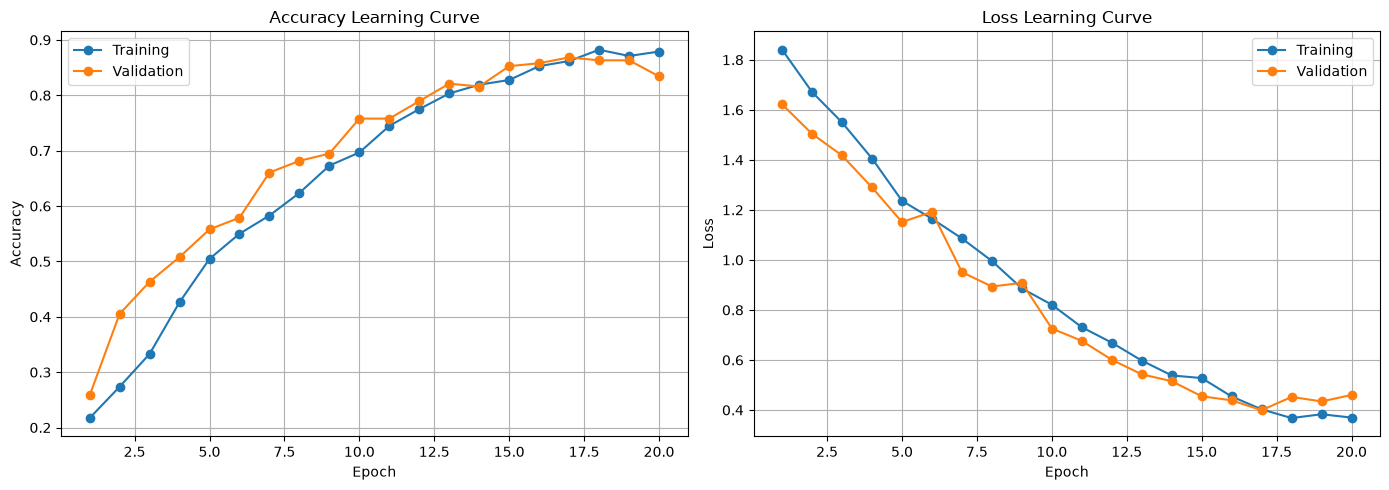

Final training accuracy:   0.8789
Final validation accuracy: 0.8342
Train/val accuracy gap:    0.0447 (large positive gap suggests overfitting)


In [7]:
# -----------------------------
# Learning curves: training vs validation accuracy and loss per epoch.
# A widening gap between the training and validation curves indicates overfitting.
# -----------------------------
hist = history.history
epochs_ran = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))

ax_acc.plot(epochs_ran, hist["accuracy"], marker="o", label="Training")
ax_acc.plot(epochs_ran, hist["val_accuracy"], marker="o", label="Validation")
ax_acc.set_title("Accuracy Learning Curve")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.grid(True)

ax_loss.plot(epochs_ran, hist["loss"], marker="o", label="Training")
ax_loss.plot(epochs_ran, hist["val_loss"], marker="o", label="Validation")
ax_loss.set_title("Loss Learning Curve")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.legend()
ax_loss.grid(True)

plt.tight_layout()
plt.show()

final_gap = hist["accuracy"][-1] - hist["val_accuracy"][-1]
print(f"Final training accuracy:   {hist['accuracy'][-1]:.4f}")
print(f"Final validation accuracy: {hist['val_accuracy'][-1]:.4f}")
print(f"Train/val accuracy gap:    {final_gap:.4f} (large positive gap suggests overfitting)")

##### 7. Performance Visualization

 1/15 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Clean 0.2 Test Set accuracy: 0.8761


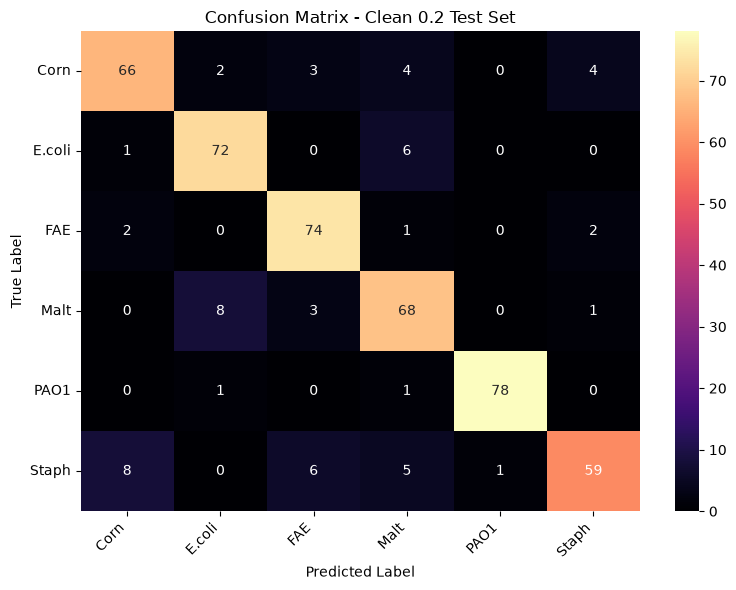

Classification Report - Clean 0.2 Test Set:

              precision    recall  f1-score   support

        Corn       0.86      0.84      0.85        79
      E.coli       0.87      0.91      0.89        79
         FAE       0.86      0.94      0.90        79
        Malt       0.80      0.85      0.82        80
        PAO1       0.99      0.97      0.98        80
       Staph       0.89      0.75      0.81        79

    accuracy                           0.88       476
   macro avg       0.88      0.88      0.88       476
weighted avg       0.88      0.88      0.88       476



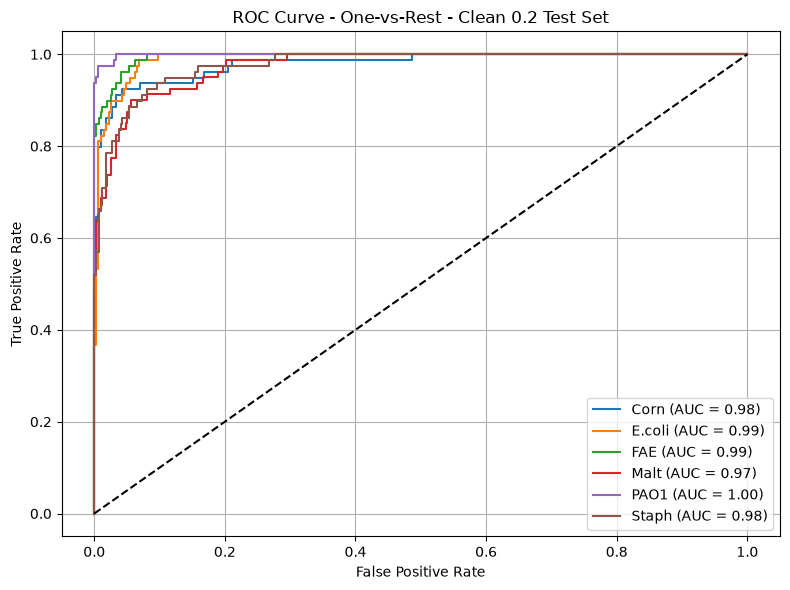

 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


Noisy 0.2 Test Set accuracy: 0.8739


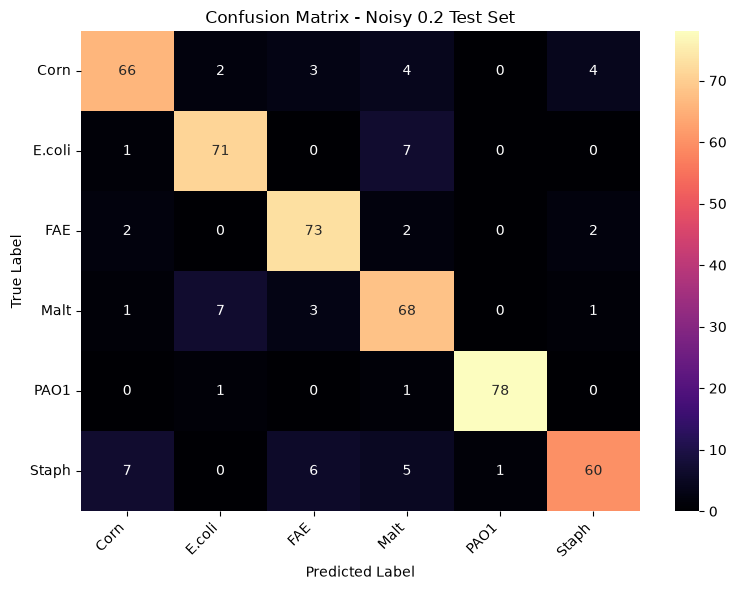

Classification Report - Noisy 0.2 Test Set:

              precision    recall  f1-score   support

        Corn       0.86      0.84      0.85        79
      E.coli       0.88      0.90      0.89        79
         FAE       0.86      0.92      0.89        79
        Malt       0.78      0.85      0.81        80
        PAO1       0.99      0.97      0.98        80
       Staph       0.90      0.76      0.82        79

    accuracy                           0.87       476
   macro avg       0.88      0.87      0.87       476
weighted avg       0.88      0.87      0.87       476



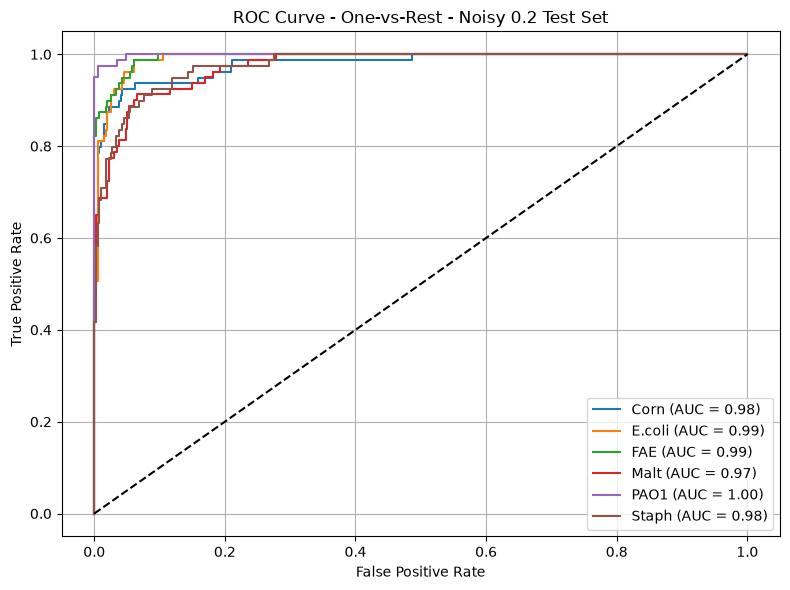

Accuracy comparison:
Clean 0.2 test accuracy: 0.8761
Noisy 0.2 test accuracy: 0.8739
Accuracy drop from white noise: 0.0021


In [8]:
# -----------------------------
# Load readable class names
# -----------------------------
# Build the encoded-integer -> original class label map straight from df (which still
# holds both the 'target' string and its 'target_encoded' value). Doing it here means
# this cell never depends on target_encoding_map.json having been exported.
_label_pairs = df[["target_encoded", "target"]].drop_duplicates()
reverse_target_map = {
    int(encoded): str(label)
    for encoded, label in zip(_label_pairs["target_encoded"], _label_pairs["target"])
}

# Make labels in the correct numeric order
labels = [reverse_target_map[i] for i in range(n_classes)]
class_ids = list(range(n_classes))
y_true = np.argmax(y_test, axis=1)
y_true_bin = label_binarize(y_true, classes=class_ids)
if y_true_bin.shape[1] == 1:
    # Binary case (2 classes): label_binarize returns a single column, but the
    # softmax output and the per-class ROC loop expect one column per class.
    y_true_bin = np.hstack([1 - y_true_bin, y_true_bin])


def get_unique_export_path(file_name):
    """Return a non-overwriting file path by appending a counter if needed."""
    base_name, ext = os.path.splitext(file_name)
    candidate = file_name
    counter = 1

    while os.path.exists(candidate):
        candidate = f"{base_name}_{counter}{ext}"
        counter += 1

    return candidate


def evaluate_transformer_test_set(
    X_eval, y_true, dataset_name, show_roc=True,
    report_filename="classification_report.csv", export_class_report=False,
):
    # -----------------------------
    # Predict on test set
    # -----------------------------
    y_pred_probs = model.predict(X_eval)
    y_pred = np.argmax(y_pred_probs, axis=1)
    accuracy = accuracy_score(y_true, y_pred)

    print(f"{dataset_name} accuracy: {accuracy:.4f}")

    # -----------------------------
    # Confusion matrix
    # -----------------------------
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='magma',
        cbar=True,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Classification report
    # -----------------------------
    print(f"Classification Report - {dataset_name}:\n")
    report = classification_report(y_true, y_pred, target_names=labels, zero_division=0)
    print(report)

    # Optionally export the classification report as a CSV (like the RF/XG notebooks).
    report_dict = classification_report(
        y_true, y_pred, target_names=labels, output_dict=True, zero_division=0
    )
    report_df = pd.DataFrame(report_dict).transpose()
    report_export_path = get_unique_export_path(report_filename)
    if export_class_report:
        report_df.to_csv(report_export_path, index=True)
        print(f"Classification report CSV saved to: {report_export_path}")

    # -----------------------------
    # ROC Curve (One-vs-Rest)
    # -----------------------------
    if show_roc:
        plt.figure(figsize=(8, 6))

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{labels[i]} (AUC = {roc_auc:.2f})")

        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f"ROC Curve - One-vs-Rest - {dataset_name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": accuracy,
        "y_pred": y_pred,
        "y_pred_probs": y_pred_probs,
        "confusion_matrix": cm,
        "classification_report_csv_path": report_export_path,
    }


clean_results = evaluate_transformer_test_set(
    X_test, y_true, "Clean 0.2 Test Set",
    report_filename="classification_report_clean.csv",
    export_class_report=False,
)
noisy_results = evaluate_transformer_test_set(
    X_test_noisy, y_true, "Noisy 0.2 Test Set",
    report_filename="classification_report_noisy.csv",
    export_class_report=False,
)

print("Accuracy comparison:")
print(f"Clean 0.2 test accuracy: {clean_results['accuracy']:.4f}")
print(f"Noisy 0.2 test accuracy: {noisy_results['accuracy']:.4f}")
print(f"Accuracy drop from white noise: {clean_results['accuracy'] - noisy_results['accuracy']:.4f}")

##### 7b. Train vs Test Accuracy
This cell reports training accuracy next to the test accuracy so the train/test gap (a quick overfitting check) is visible alongside the accuracy comparison.

In [9]:
# -----------------------------
# Train accuracy vs. test accuracy (overfitting gap)
# -----------------------------
# Adds the model's accuracy on the training set next to the clean/noisy test
# accuracies reported above. A large train/test gap is a sign of overfitting.
train_accuracy = accuracy_score(
    np.argmax(y_train, axis=1),
    np.argmax(model.predict(X_train), axis=1)
)

print("Accuracy comparison (train vs test):")
print(f"Train accuracy:           {train_accuracy:.4f}")
print(f"Clean 0.2 test accuracy:  {clean_results['accuracy']:.4f}")
print(f"Noisy 0.2 test accuracy:  {noisy_results['accuracy']:.4f}")
print(f"Train/clean-test gap:     {train_accuracy - clean_results['accuracy']:.4f}")

 1/60 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

27/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

51/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


Accuracy comparison (train vs test):
Train accuracy:           0.8963
Clean 0.2 test accuracy:  0.8761
Noisy 0.2 test accuracy:  0.8739
Train/clean-test gap:     0.0203


##### 8. Cross-Validation Accuracy (5-Fold)
- 5-fold stratified cross-validation, reported like the RF and XGBoost notebooks (per-fold scores, mean, std).
- Each fold rebuilds and retrains the transformer from the best hyperparameters, then scores accuracy on the held-out fold.
- The `StandardScaler` is refit inside each fold so no validation data leaks into preprocessing.
- Cross-validation runs on the clean spectra the model is trained on; the noisy test set is kept separate, as in section 7.

In [10]:
# -----------------------------------------------------------------------------
# 5-Fold Cross-Validation Accuracy
# -----------------------------------------------------------------------------
# Same cross-validation accuracy report as the RF and XGBoost notebooks, adapted
# for a Keras model. scikit-learn's cross_val_score cannot train a Keras network,
# so the 5 folds are run by hand with StratifiedKFold: each fold rebuilds the
# transformer from the best hyperparameters, trains on the training split, and
# scores accuracy on the held-out split. The StandardScaler is refit inside every
# fold (on training rows only), which is the leak-free way cross_val_score refits
# the RF/XG estimators per fold. Cross-validation uses the clean spectra the model
# trains on; the noisy set is kept separate, matching the clean-train design.

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_scores = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    # Refit the scaler on this fold's training rows only, then apply to both splits.
    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X[train_idx]).astype(np.float32)
    X_val = fold_scaler.transform(X[val_idx]).astype(np.float32)

    # StratifiedKFold returns ascending indices, so shuffle the training fold to keep
    # Keras's validation_split (its last 20%, taken before shuffling) representative.
    rng = np.random.default_rng(42 + fold)
    perm = rng.permutation(X_tr.shape[0])
    X_tr = X_tr[perm][..., np.newaxis]
    y_tr = to_categorical(y[train_idx][perm], num_classes=n_classes).astype(np.float32)

    X_val = X_val[..., np.newaxis]
    y_val = to_categorical(y[val_idx], num_classes=n_classes).astype(np.float32)

    # Rebuild and retrain a fresh model so folds never share weights, using the same
    # callbacks, epoch budget, and batch size as the final model trained above.
    K.clear_session()
    fold_model = build_transformer_model(best_params)
    fold_callbacks = [
        StopOnValidationLossIncrease(monitor="val_loss", min_delta=0.0),
        EarlyStopping(
            monitor="val_loss", patience=3, min_delta=0.0,
            restore_best_weights=True, verbose=0
        ),
    ]
    fold_model.fit(
        X_tr, y_tr,
        validation_split=0.2,
        epochs=best_epochs,
        batch_size=best_batch_size,
        callbacks=fold_callbacks,
        verbose=0
    )

    fold_acc = fold_model.evaluate(X_val, y_val, verbose=0)[1]
    cv_scores.append(fold_acc)
    print(f"Fold {fold}/{N_SPLITS} accuracy: {fold_acc:.4f}")

cv_scores = np.array(cv_scores)

print("\nCross-Validation Accuracy Scores:", np.round(cv_scores, 4))
print("CV Mean Accuracy:", round(cv_scores.mean(), 4))
print("CV Std Dev:", round(cv_scores.std(), 4))

Validation loss rose at epoch 12: val_loss=0.7727 > best_val_loss=0.7086 from epoch 11. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 16: val_loss=0.5473 > best_val_loss=0.5268 from epoch 15. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 20: val_loss=0.4406 > best_val_loss=0.4240 from epoch 19. EarlyStopping(patience=3) decides when to stop.
Validation loss rose at epoch 21: val_loss=0.4662 > best_val_loss=0.4240 from epoch 19. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 22: val_loss=0.4856 > best_val_loss=0.4240 from epoch 19. EarlyStopping(patience=3) decides when to stop.
Fold 1/5 accuracy: 0.8908


Validation loss rose at epoch 16: val_loss=0.5731 > best_val_loss=0.4805 from epoch 15. EarlyStopping(patience=3) decides when to stop.
Validation loss rose at epoch 17: val_loss=0.4955 > best_val_loss=0.4805 from epoch 15. EarlyStopping(patience=3) decides when to stop.


...

Validation loss rose at epoch 11: val_loss=0.7843 > best_val_loss=0.7638 from epoch 10. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 16: val_loss=0.5296 > best_val_loss=0.5200 from epoch 15. EarlyStopping(patience=3) decides when to stop.
Validation loss rose at epoch 17: val_loss=0.5721 > best_val_loss=0.5200 from epoch 15. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 22: val_loss=0.5120 > best_val_loss=0.4252 from epoch 21. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 26: val_loss=0.4363 > best_val_loss=0.3795 from epoch 25. EarlyStopping(patience=3) decides when to stop.
Validation loss rose at epoch 27: val_loss=0.4072 > best_val_loss=0.3795 from epoch 25. EarlyStopping(patience=3) decides when to stop.


Validation loss rose at epoch 28: val_loss=0.4624 > best_val_loss=0.3795 from epoch 25. EarlyStopping(patience=3) decides when to stop.
Fold 5/5 accuracy: 0.9032

Cross-Validation Accuracy Scores: [0.8908 0.8653 0.8379 0.9116 0.9032]
CV Mean Accuracy: 0.8817
CV Std Dev: 0.0269
